# 03 -- Isolation by distance

Computes linearized pairwise site-level Fst and regresses against geographic distance.

**Inputs**
- `table_S1.tsv` --> STAGdb metadata for samples included in manuscript
- `mac_ld.gt_matrix.int8.npz` from `convert_vcf_to_npz.py` --> not downsampled, no global MAF filter


**Outputs**
- `apal_ibd.tsv` --> filtered and merged sites for IBD analysis
- `lin_fst_sites.tsv` --> linearized site-level pairwise Fst table
- `ibd_florida.pdf`
- `ibd_greater_antilles.pdf`

---

## Imports and paths

In [1]:
from __future__ import annotations

import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.insert(0, str(Path("../scripts")))

from gt_io import load_cache_npz, write_cache_npz, basic_parse_report

from popgen_utils import (
    build_symmetric_pair_matrix,
    compute_ibd_stats_from_long_df,
    dosage_to_genotype_array,
    fst_mat_to_nm_long,
    fst_pair_with_nloci,
    haversine_km,
    linearized_fst,
    mantel_test,
    order_sites_greedy_nn,
)

import plotly.express as px


In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)

In [3]:
PROJECT_DIR = Path("/Users/kidelu001/awi-work/science/projects/apal_popgen/github")
# PROJECT_DIR = Path(/path/to/your/project)

# input
META_TSV  = PROJECT_DIR / "table_S1_metadata.tsv"

DATA_DIR = Path("/Users/kidelu001/awi-work/science/projects/apal_popgen/deriv/manuscript")

NPZ = DATA_DIR / "maf_ld_prev.gt_matrix.int8.npz"

------

## IBD functions

In [4]:
def build_panel(apal_ibd, gt, subregion, site_merge_fn=None, site_merge_map=None):
    """
    Filter to subregion, apply site merges, align to NPZ order,
    deduplicate (one sample per MLG × site), filter by min genets,
    and return a trimmed GenotypeArray.

    Parameters
    ----------
    site_merge_fn  : callable  – e.g. a custom function
    site_merge_map : dict      – e.g. GA_SITE_MERGE_MAP or FL_SITE_MERGE_MAP

    Returns
    -------
    panel       : pd.DataFrame  sample metadata aligned to gta columns
    site_coords : pd.DataFrame  per-site centroid + n_genets
    gta         : allel.GenotypeArray
    """
    panel = apal_ibd[apal_ibd[IBD_COL] == subregion].copy()

    if site_merge_fn is not None:
        panel["site_merged"] = panel[SITE_COL].map(site_merge_fn)
    elif site_merge_map is not None:
        panel["site_merged"] = panel[SITE_COL].map(lambda x: site_merge_map.get(x, x))
    else:
        panel["site_merged"] = panel[SITE_COL]

    # align to NPZ sample order
    npz_lookup = {s: i for i, s in enumerate(gt.sample_ids)}
    panel = panel[panel[ID_COL].isin(npz_lookup)].copy()
    panel["_npz_idx"] = panel[ID_COL].map(npz_lookup)
    panel = panel.sort_values("_npz_idx").reset_index(drop=True)

    # deduplicate: one sample per (MLG, merged site)
    panel = (
        panel
        .drop_duplicates(subset=[MLG_COL, "site_merged"], keep="first")
        .reset_index(drop=True)
    )

    # filter sites by min_genets
    site_n = panel.groupby("site_merged")[MLG_COL].nunique()
    valid  = site_n[site_n >= MIN_GENETS_PER_SITE].index
    panel  = panel[panel["site_merged"].isin(valid)].copy().reset_index(drop=True)

    # site centroids and genet counts
    site_coords = (
        panel.groupby("site_merged")
        .agg(
            lat_median=(LAT_COL, "median"),
            lon_median=(LON_COL, "median"),
            n_genets=(MLG_COL, "nunique"),
        )
        .reset_index()
        .rename(columns={"site_merged": "site"})
    )

    # subset genotype matrix and build GenotypeArray
    G_sub = gt.G[:, panel["_npz_idx"].to_numpy()]
    gta   = dosage_to_genotype_array(G_sub)

    return panel, site_coords, gta


def compute_pairwise_fst(panel, gta):
    """Weir-Cockerham FST for all site pairs. Returns a long DataFrame."""
    sites = sorted(panel["site_merged"].unique())
    rows  = []
    for s1, s2 in itertools.combinations(sites, 2):
        mask1 = (panel["site_merged"] == s1).values
        mask2 = (panel["site_merged"] == s2).values
        fst, n_loci = fst_pair_with_nloci(gta, mask1, mask2)
        rows.append({"site1": s1, "site2": s2, "fst": fst, "n_loci": n_loci})
    return pd.DataFrame(rows)


def build_ibd_df(fst_df, site_coords_ordered, site_region=None):
    """
    Add linearized FST, geographic distance, along-tract distance,
    and optionally a pair_group column for coloring.

    Parameters
    ----------
    site_region : dict, optional
        Mapping of site name → region label (e.g. "Puerto Rico", "USVI").
        When provided, adds a ``pair_group`` column: within-region pairs
        get the region label; cross-region pairs get "A × B".
    """
    df            = fst_df.copy()
    df["linearized_fst"] = df["fst"].apply(linearized_fst)
    coord = site_coords_ordered.set_index("site")[["lat_median", "lon_median", "tract_km"]]

    df["geo_dist_km"] = df.apply(lambda r: haversine_km(
        coord.loc[r["site1"], "lat_median"], coord.loc[r["site1"], "lon_median"],
        coord.loc[r["site2"], "lat_median"], coord.loc[r["site2"], "lon_median"],
    ), axis=1)
    df["along_tract_km"] = df.apply(lambda r: abs(
        coord.loc[r["site1"], "tract_km"] - coord.loc[r["site2"], "tract_km"]
    ), axis=1)

    if site_region is not None:
        def _pair_group(r):
            g1 = site_region.get(r["site1"], "Unknown")
            g2 = site_region.get(r["site2"], "Unknown")
            a, b = sorted([g1, g2])
            return f"{a}–{b}"
        df["pair_group"] = df.apply(_pair_group, axis=1)
        df["pair_type"]  = df.apply(
            lambda r: "within" if
            site_region.get(r["site1"]) == site_region.get(r["site2"])
            else "between", axis=1
        )

    return df


def plot_ibd(ibd_df, x_col="geo_dist_km", y_col="linearized_fst",
             title="IBD", save_base=None, figsize=(6,4),
             hue_col=None, pair_colors=None, markers=None):
    """
    IBD scatter with OLS regression line and annotated statistics.

    Parameters
    ----------
    hue_col : str, optional
        Column in ibd_df to color points by (e.g. ``'pair_group'``).
    pair_colors : dict, optional
        Mapping of pair_group label → hex color.
        Keys absent from the data are ignored automatically.
    markers : dict, optional
        Keys ``'within_region'`` and ``'between_region'`` → matplotlib marker.
        Requires ``pair_type`` column in ibd_df (added by build_ibd_df).
    """
    extra_cols = [c for c in [hue_col, "pair_type"]
                  if c and c in ibd_df.columns]
    cols = [x_col, y_col] + extra_cols
    df   = ibd_df[cols].dropna(subset=[x_col, y_col])
    x, y = df[x_col].values, df[y_col].values

    ols    = stats.linregress(x, y)
    r2     = ols.rvalue ** 2
    istats = compute_ibd_stats_from_long_df(
        ibd_df, x_col=x_col, y_col=y_col, n_perm=N_MANTEL_PERM
    )

    fig, ax = plt.subplots(figsize=figsize)

    if hue_col is not None:
        groups = sorted(df[hue_col].unique())
        if pair_colors is None:
            cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
            _colors = {g: cycle[i % len(cycle)] for i, g in enumerate(groups)}
        else:
            _colors = {g: pair_colors[g] for g in groups if g in pair_colors}
        _has_type = "pair_type" in df.columns and markers is not None
        for grp, grp_df in df.groupby(hue_col):
            _color  = _colors.get(grp, "grey")
            _marker = "o"
            if _has_type:
                _ptype  = grp_df["pair_type"].iloc[0]
                _marker = markers.get(f"{_ptype}_region", "o")
            ax.scatter(
                grp_df[x_col], grp_df[y_col],
                s=40, edgecolors="k", linewidths=0.5, alpha=0.85,
                color=_color, marker=_marker, label=grp, zorder=3,
            )
        ax.legend(
            title="Region pair", fontsize=7, title_fontsize=8,
            bbox_to_anchor=(1.02, 1), loc="upper left",
            borderaxespad=0, framealpha=0.9,
        )
    else:
        ax.scatter(x, y, s=40, edgecolors="k", linewidths=0.5, alpha=0.8, zorder=3)

    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, ols.slope * xline + ols.intercept, color="0.4", lw=1)

    label = (
        f"$R^2$ = {r2:.3f}  (p = {istats['ols_p']:.3f})\n"
        f"Mantel r = {istats['mantel_r']:.3f}  (p = {istats['mantel_p']:.3f})\n"
        f"n pairs = {istats['n_pairs']}"
    )
    ax.text(1.02, 0.0, label, transform=ax.transAxes, fontsize=8,
        ha="left", va="bottom",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8", alpha=0.9))

    ax.set_xlabel("Geographic distance (km)")
    ax.set_ylabel("$F_{ST}$ / (1 \u2212 $F_{ST}$)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()

    if save_base is not None:
        for ext in ("pdf", "eps"):
            fig.savefig(f"{save_base}.{ext}", bbox_inches="tight")
        print(f"Saved \u2192 {save_base}.pdf / .eps")

    plt.show()
    return istats


----
## Filter metadata to IBD sites

In [5]:
meta = pd.read_csv(META_TSV, sep="\t", low_memory=False)

In [6]:
ID_COL          = "affymetrix_id"
SPECIES_COL     = "species"
MLG_COL         = "mlg"
REGION_COL      = "region"
SUBREGION_COL   = "region_sub"
REEF_COL        = "reef"
LAT_COL         = "lat_clean"
LON_COL         = "lon_clean"
NURSERY_COL     = "is_nursery"
 

In [7]:
apal_wild = meta.loc[
    ~meta[NURSERY_COL].fillna(False)
].copy().reset_index(drop=True)

apal_wild.shape


(2632, 25)

In [8]:
# ── Site-level nursery fraction diagnostic ──────────────────────────────────
# Before the wild filter, look at what fraction of each site is nursery-flagged.
# Sites with very high nursery fractions may warrant manual exclusion even after
# individual nursery rows are removed (the remaining 'wild' samples at a nursery
# facility may not represent natural wild populations).
#
# CRF  = Coral Restoration Foundation – this is a nursery operator;
#        map entry 'CRF' → 'Conch' merges those samples into the Conch Reef pool.
# Mote = Mote Marine Laboratory      – research/restoration facility.
# Inspect the table below and add any high-fraction sites to NURSERY_SITE_EXCLUDE.

_site_nursery = (
    meta.groupby([REGION_COL, REEF_COL], dropna=False)
    .agg(
        n_total  =(ID_COL,       "size"),
        n_nursery=(NURSERY_COL,  lambda s: s.fillna(False).sum()),
    )
    .reset_index()
)
_site_nursery["frac_nursery"] = (_site_nursery["n_nursery"]
                                  / _site_nursery["n_total"])
_site_nursery["n_wild"] = (_site_nursery["n_total"]
                            - _site_nursery["n_nursery"])

# Show only sites that have at least one nursery-flagged sample
_site_nursery.loc[
    _site_nursery["n_nursery"] > 0
].sort_values("frac_nursery", ascending=False).reset_index(drop=True)


,region,reef,n_total,n_nursery,frac_nursery,n_wild
0,Belize,Carne Nursery,5,5,1.0,0
1,Florida,Sombrero Reef-Outplants,18,18,1.0,0
2,Florida,MML Ex-situ Nursery IC2R8,1,1,1.0,0
3,Florida,MML Ex-situ Nursery IC2R9,1,1,1.0,0
4,Florida,MML Ex-situ Nursery Islamorada,10,10,1.0,0
5,Florida,MML Ex-situ nursery Key Largo,27,27,1.0,0
6,Florida,MML International Gene Bank,225,225,1.0,0
7,Florida,MML Looe Key Nursery,35,35,1.0,0
8,Florida,MML Sand Key Nursery,3,3,1.0,0
9,Florida,North Dry Rocks Outplant,3,3,1.0,0


In [9]:
# ── Manual site-level nursery exclusions ─────────────────────────────────────
# Some nursery / restoration / captive-facility sites are NOT flagged is_nursery=True
# in the metadata, so they pass the per-sample filter above. Exclude them here.
#
# NURSERY_SITE_EXCLUDE : exact REEF_COL values to drop
# NURSERY_SITE_PATTERNS: regex patterns applied to REEF_COL (re.search, case-sensitive)
#   'OP'   – outplanting-plot sites (OP1, OP-Carysfort, etc.)
#   'Mote' – Mote Marine Laboratory
#   'FLAQ' – Florida Aquarium

NURSERY_SITE_EXCLUDE: list[str] = [
    # exact reef names — add / remove as needed
    # "CRF",  # Coral Restoration Foundation (already mapped → Conch via FL_SITE_MERGE_MAP;
    #          # add here instead if you distrust the surviving 'wild' CRF rows entirely)
]

NURSERY_SITE_PATTERNS: list[str] = [
    r"OP",    # outplanting sites (OP1, OP2, OP-*, etc.)
    r"Mote",  # Mote Marine Laboratory
    r"FLAQ",  # Florida Aquarium
]

_before = len(apal_wild)
_reef_str = apal_wild[REEF_COL].fillna("")

_exact_mask = apal_wild[REEF_COL].isin(NURSERY_SITE_EXCLUDE)
_pat_mask   = (
    _reef_str.str.contains("|".join(NURSERY_SITE_PATTERNS), regex=True)
    if NURSERY_SITE_PATTERNS
    else pd.Series(False, index=apal_wild.index)
)

# Show which reef names are caught before removing them
_caught = apal_wild.loc[_exact_mask | _pat_mask, REEF_COL].value_counts()
if not _caught.empty:
    print("Reef names removed by site-level nursery exclusion:")
    print(_caught.to_string())

apal_wild = apal_wild.loc[
    ~(_exact_mask | _pat_mask)
].reset_index(drop=True)

_n_removed = _before - len(apal_wild)
print(f"\nRows removed : {_n_removed:,}")
print(f"Remaining    : {len(apal_wild):,} wild samples")
apal_wild.shape


No site-level nursery exclusions applied.


(2632, 25)

In [10]:
apal_wild['subregion_ibd'] = 'Exclude'

florida_regions = ['Florida']
grant_regions = ['Dominican Republic', 'Puerto Rico', 'USVI']

apal_wild.loc[apal_wild[REGION_COL].isin(florida_regions), 'subregion_ibd'] = 'Florida'
apal_wild.loc[apal_wild[REGION_COL].isin(grant_regions), 'subregion_ibd'] = 'GreaterAntilles'

apal_wild['subregion_ibd'].value_counts(dropna=False)


subregion_ibd
Florida            1453
Exclude             608
GreaterAntilles     571
Name: count, dtype: int64

----
## Greater Antilles

In [11]:
grant_df = apal_wild.loc[
    apal_wild["subregion_ibd"] == "GreaterAntilles"
].copy().reset_index(drop=True)

In [12]:
grant_site_counts = (
    grant_df.groupby([SUBREGION_COL, REEF_COL], dropna=False)
    .agg(
        # n_rows=(ID_COL, "size"),
        n_genets=(MLG_COL, lambda s: s.nunique(dropna=True)),
        lat_clean=(LAT_COL, "median"),
        lon_clean=(LON_COL, "median"),
    )
    .reset_index()
    .sort_values(["n_genets", SUBREGION_COL, REEF_COL], ascending=[False, True, True])
    .reset_index(drop=True)
)

grant_site_counts

,region_sub,reef,n_genets,lat_clean,lon_clean
0,Puerto Rico,Gilligan's Reef,29,17.939170,-66.869200
1,Dominican Republic,PuntaCana,28,18.527480,-68.357600
2,USVI,Buck Island,19,17.780760,-64.587480
3,USVI,Rust Op Twist,17,17.782790,-64.792010
4,Dominican Republic,Catalina,16,18.376290,-69.008500
5,Dominican Republic,Minitas,16,18.401240,-68.920900
6,Puerto Rico,Cayo Lajas,15,17.937500,-66.899400
7,Puerto Rico,Cayo Coral HMO5,14,17.937620,-66.890900
8,Puerto Rico,Laurel,14,17.941900,-67.057500
9,Puerto Rico,Penon Moncho Diaz,14,18.472240,-66.478700


## Plot current site maps

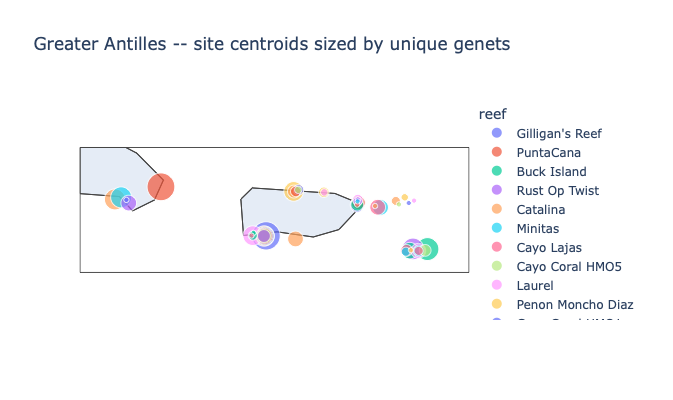

In [13]:
fig = px.scatter_geo(
    grant_site_counts,
    lat=LAT_COL,
    lon=LON_COL,
    color=REEF_COL,
    size="n_genets",
    hover_name=SUBREGION_COL,
    hover_data=[SUBREGION_COL, REEF_COL, "n_genets"],
    title="Greater Antilles -- site centroids sized by unique genets",
)

fig.update_geos(
    scope="world",
    projection_type="natural earth",
    showcountries=True,
    showcoastlines=True,
    lataxis_range=[17.5, 19.0],
    lonaxis_range=[-69.5, -64.0],
)

fig.update_layout(height=400)
fig.show()

In [14]:
grant_df["merged_site"] = grant_df[REEF_COL]

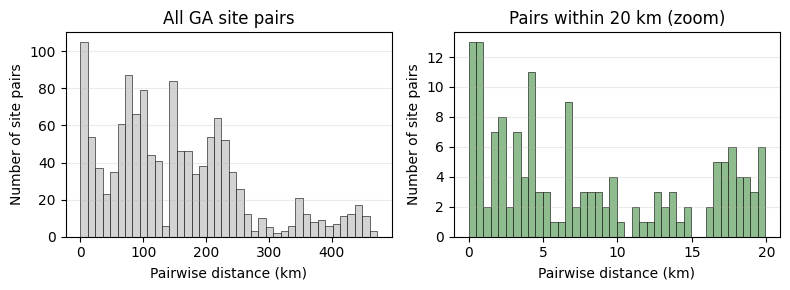

Candidate proximity merges (≤ 10 km, same subregion):


In [15]:
# MIN_GENETS_PER_SITE = 5

# explore inter-site distances for proximity-based merges
ga_site_coords_raw = (
    grant_df.groupby(REEF_COL)
    .agg(
        lat_median=(LAT_COL,      "median"),
        lon_median=(LON_COL,      "median"),
        n_genets  =(MLG_COL,      "nunique"),
        subregion =(SUBREGION_COL, "first"),
    )
    .reset_index()
    .rename(columns={REEF_COL: "site"})
)

# pairwise distances (all site pairs)
_sites = ga_site_coords_raw["site"].tolist()
_dist_rows = []
for _i, _s1 in enumerate(_sites):
    for _j, _s2 in enumerate(_sites):
        if _j <= _i:
            continue
        _r1 = ga_site_coords_raw.loc[ga_site_coords_raw["site"] == _s1].iloc[0]
        _r2 = ga_site_coords_raw.loc[ga_site_coords_raw["site"] == _s2].iloc[0]
        _d  = haversine_km(_r1["lat_median"], _r1["lon_median"],
                           _r2["lat_median"], _r2["lon_median"])
        _dist_rows.append({
            "site1":  _s1,           "n1":   int(_r1["n_genets"]),
            "site2":  _s2,           "n2":   int(_r2["n_genets"]),
            "sub1":   _r1["subregion"],       
            "sub2":   _r2["subregion"],      
            "dist_km": _d,
        })

ga_dist_df = pd.DataFrame(_dist_rows)

# distance distribution plots
fig, axes = plt.subplots(1, 2, figsize=(8,3))

axes[0].hist(ga_dist_df["dist_km"], bins=40, edgecolor="k", linewidth=0.4, color="lightgrey")
axes[0].set_xlabel("Pairwise distance (km)")
axes[0].set_ylabel("Number of site pairs")
axes[0].set_title("All GA site pairs")
axes[0].grid(True, alpha=0.25, axis="y")

_close = ga_dist_df[ga_dist_df["dist_km"] <= 20]
axes[1].hist(_close["dist_km"], bins=40, edgecolor="k", linewidth=0.4, color="darkseagreen")
axes[1].set_xlabel("Pairwise distance (km)")
axes[1].set_ylabel("Number of site pairs")
axes[1].set_title("Pairs within 20 km (zoom)")
axes[1].grid(True, alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

# candidate merges
PROX_THRESH_KM = 10

ga_merge_candidates = ga_dist_df[
    (ga_dist_df["sub1"] == ga_dist_df["sub2"]) &
    (ga_dist_df["dist_km"] <= PROX_THRESH_KM)
].sort_values("dist_km").reset_index(drop=True)

print(f"Candidate proximity merges (≤ {PROX_THRESH_KM} km, same subregion):")


In [16]:
ga_merge_candidates.sort_values(
    ["sub1", "dist_km"], ascending=[True, True]
)[["sub1", "site1", "n1", "site2", "n2", "dist_km"]].reset_index(drop=True)

,sub1,site1,n1,site2,n2,dist_km
0,Dominican Republic,Reef Balls,9,Sombrero,1,5.568270
1,Dominican Republic,Minitas,16,Sombrero,1,8.538613
2,Dominican Republic,Catalina,16,Minitas,16,9.650665
3,Puerto Rico,Laurel,14,San Cristobal,3,0.000000
4,Puerto Rico,Cayo Largo,1,Cayo Largo North,6,0.000000
5,Puerto Rico,Cayo Largo South,4,Lobos,1,0.000000
6,Puerto Rico,Cayo Lajas,15,Coral Uberbs,6,0.000000
7,Puerto Rico,Cayo Largo Norte,7,Cayo Largo North,6,0.011071
8,Puerto Rico,Cayo Largo,1,Cayo Largo Norte,7,0.011071
9,Puerto Rico,Cayo Coral HMO4,10,Cayo Coral HMO5,14,0.117132


In [17]:
# long-format df for merge candidates
# one row per (candidate pair × site)
_pair_rows = []
for _idx, _row in ga_merge_candidates.iterrows():
    _label = f"{_row['site1']} ↔ {_row['site2']}"
    for _site, _partner in ((_row['site1'], _row['site2']),
                             (_row['site2'], _row['site1'])):
        _info = ga_site_coords_raw.loc[ga_site_coords_raw['site'] == _site].iloc[0]
        _pair_rows.append({
            'site':       _site,
            'subregion':  _row['sub1'],
            'pair_label': _label,
            'partner':    _partner,
            'dist_km':    round(float(_row['dist_km']), 1),
            'n_genets':   int(_info['n_genets']),
            'lat':        _info['lat_median'],
            'lon':        _info['lon_median'],
        })

_merge_plot_df = (
    pd.DataFrame(_pair_rows)
    .drop_duplicates(subset=['site', 'pair_label'])
    .reset_index(drop=True)
)
print(f"{len(_merge_plot_df)} rows | {_merge_plot_df['pair_label'].nunique()} candidate pairs")


202 rows | 101 candidate pairs


## Plot candidate merge maps

In [18]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [19]:
# ── build a distance matrix over all GA sites ──────────────────────────────
_site_list = ga_site_coords_raw["site"].tolist()
_n         = len(_site_list)
_dist_mat  = np.zeros((_n, _n))

for _i in range(_n):
    for _j in range(_i + 1, _n):
        _r1, _r2 = ga_site_coords_raw.iloc[_i], ga_site_coords_raw.iloc[_j]
        _d = haversine_km(_r1["lat_median"], _r1["lon_median"],
                          _r2["lat_median"], _r2["lon_median"])
        _dist_mat[_i, _j] = _dist_mat[_j, _i] = _d

# ── complete-linkage clustering: threshold = PROX_THRESH_KM ────────────────
PROX_THRESH_KM = 10

_Z       = linkage(squareform(_dist_mat), method="complete")
_labels  = fcluster(_Z, t=PROX_THRESH_KM, criterion="distance")

ga_site_coords_raw["prox_cluster"] = _labels

# ── build a proximity merge map from clusters that have > 1 site ───────────
_cluster_sizes = ga_site_coords_raw.groupby("prox_cluster")["site"].count()
_multi_clusters = _cluster_sizes[_cluster_sizes > 1].index

GA_PROX_MERGE_MAP = {}
for _cl in _multi_clusters:
    _members = ga_site_coords_raw.loc[
        ga_site_coords_raw["prox_cluster"] == _cl, "site"
    ].tolist()
    # canonical name = member with the most genets
    _canonical = ga_site_coords_raw.loc[
        ga_site_coords_raw["site"].isin(_members)
    ].sort_values("n_genets", ascending=False).iloc[0]["site"]
    for _s in _members:
        GA_PROX_MERGE_MAP[_s] = _canonical

print(f"{len(_multi_clusters)} proximity clusters → {len(GA_PROX_MERGE_MAP)} sites remapped")
GA_PROX_MERGE_MAP

14 proximity clusters → 48 sites remapped


{'Reef Balls': 'Reef Balls',
 'Sombrero': 'Reef Balls',
 'Catalina': 'Catalina',
 'Minitas': 'Catalina',
 'Dominos East': 'Dominos East',
 'Waimea': 'Dominos East',
 'El Eco': 'Penon Moncho Diaz',
 'Los Tubos': 'Penon Moncho Diaz',
 'Penon Moncho Diaz': 'Penon Moncho Diaz',
 'Playita': 'Penon Moncho Diaz',
 'Tractores': 'Penon Moncho Diaz',
 'Cayo Coral HMO1': "Gilligan's Reef",
 'Cayo Coral HMO4': "Gilligan's Reef",
 'Cayo Coral HMO5': "Gilligan's Reef",
 'Cayo Coral HMO9': "Gilligan's Reef",
 'Cayo Lajas': "Gilligan's Reef",
 'Coral Uberbs': "Gilligan's Reef",
 "Gilligan's Reef": "Gilligan's Reef",
 'La Parguera': 'Laurel',
 'Laurel': 'Laurel',
 'San Cristobal': 'Laurel',
 'San Cristobal Forereef': 'Laurel',
 'Cayo Largo': 'Cayo Largo Norte',
 'Cayo Largo Norte': 'Cayo Largo Norte',
 'Cayo Largo North': 'Cayo Largo Norte',
 'Cayo Largo South': 'Cayo Largo Norte',
 'Cayo Largo Sur': 'Cayo Largo Norte',
 'Lobos': 'Cayo Largo Norte',
 'Noemi': 'Cayo Largo Norte',
 'Palomino (Sand Slide 

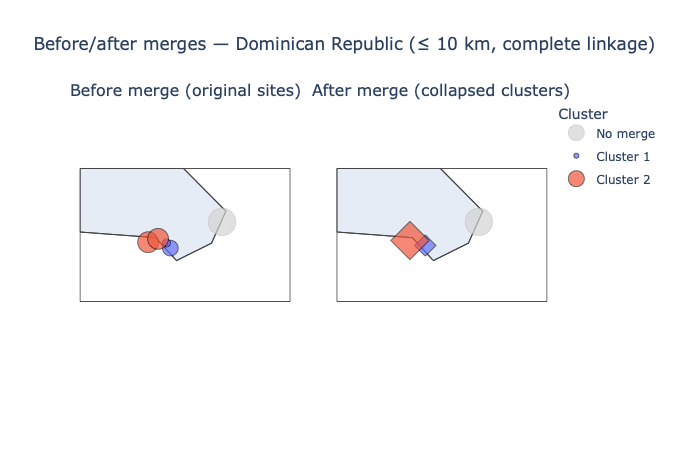

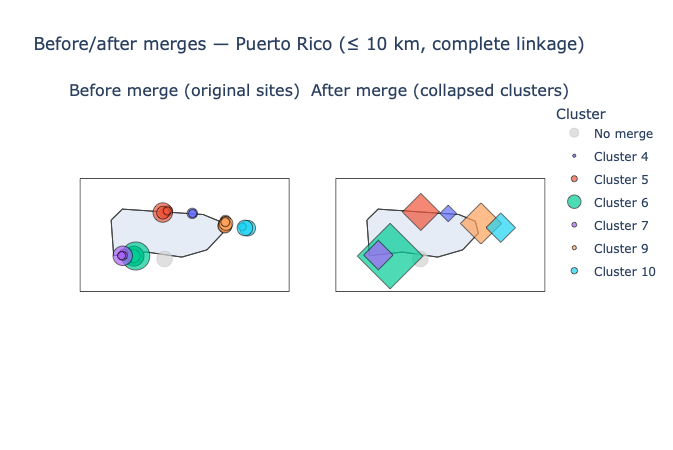

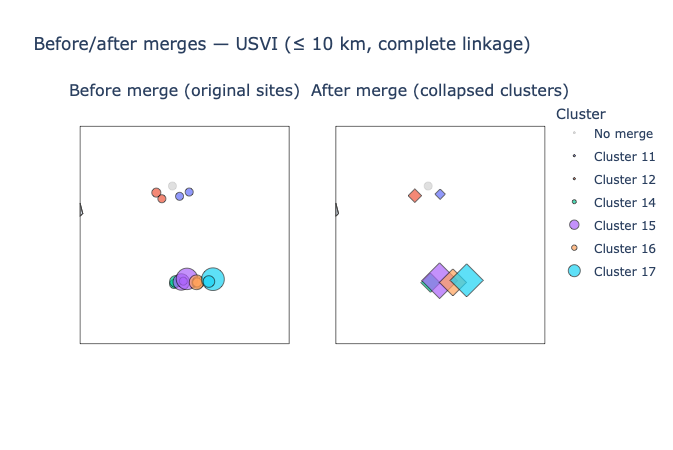

In [20]:
_max_genets = ga_site_coords_raw['n_genets'].max()
_sizeref    = 2 * _max_genets / (28 ** 2)
_PAD_LAT, _PAD_LON = 0.4, 0.6

for _sub in sorted(ga_site_coords_raw['subregion'].unique()):
    _sub_df    = ga_site_coords_raw[ga_site_coords_raw['subregion'] == _sub].copy()
    _cl_sizes  = _sub_df.groupby('prox_cluster')['site'].count()
    _multi_cls = sorted(_cl_sizes[_cl_sizes > 1].index)
    _single_cl = set(_cl_sizes[_cl_sizes == 1].index)
    _singletons = _sub_df[_sub_df['prox_cluster'].isin(_single_cl)]

    _clr_cycle = px.colors.qualitative.Plotly
    _cl_color  = {cl: _clr_cycle[i % len(_clr_cycle)]
                  for i, cl in enumerate(_multi_cls)}

    _lat_range = [_sub_df['lat_median'].min() - _PAD_LAT,
                  _sub_df['lat_median'].max() + _PAD_LAT]
    _lon_range = [_sub_df['lon_median'].min() - _PAD_LON,
                  _sub_df['lon_median'].max() + _PAD_LON]
    _geo_cfg = dict(
        scope='world', projection_type='natural earth',
        showcountries=True, showcoastlines=True,
        lataxis_range=_lat_range, lonaxis_range=_lon_range,
    )

    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'geo'}, {'type': 'geo'}]],
        subplot_titles=['Before merge (original sites)',
                         'After merge (collapsed clusters)'],
    )

    # ── grey singleton trace (shared across both panels) ─────────────────────
    def _singleton_trace(col, show_legend):
        fig.add_trace(go.Scattergeo(
            lat=_singletons['lat_median'],
            lon=_singletons['lon_median'],
            mode='markers',
            marker=dict(
                size=_singletons['n_genets'],
                sizemode='area', sizeref=_sizeref, sizemin=4,
                color='lightgrey',
                line=dict(width=0.5, color='darkgrey'),
            ),
            text=_singletons['site'],
            customdata=_singletons['n_genets'].values,
            hovertemplate='<b>%{text}</b><br>Genets: %{customdata}<extra>no merge</extra>',
            name='No merge', legendgroup='singleton', showlegend=show_legend,
        ), row=1, col=col)

    _singleton_trace(col=1, show_legend=True)
    _singleton_trace(col=2, show_legend=False)

    # ── left panel: original sites, colored by cluster ────────────────────────
    for _cl in _multi_cls:
        _cl_df   = _sub_df[_sub_df['prox_cluster'] == _cl]
        _cl_name = f'Cluster {_cl}'
        fig.add_trace(go.Scattergeo(
            lat=_cl_df['lat_median'],
            lon=_cl_df['lon_median'],
            mode='markers',
            marker=dict(
                size=_cl_df['n_genets'],
                sizemode='area', sizeref=_sizeref, sizemin=4,
                color=_cl_color[_cl],
                line=dict(width=0.8, color='black'),
            ),
            text=_cl_df['site'],
            customdata=_cl_df['n_genets'].values,
            hovertemplate='<b>%{text}</b><br>Genets: %{customdata}<extra>' + _cl_name + '</extra>',
            name=_cl_name, legendgroup=_cl_name, showlegend=True,
        ), row=1, col=1)

    # ── right panel: collapsed centroids (diamonds) ───────────────────────────
    for _cl in _multi_cls:
        _cl_df     = _sub_df[_sub_df['prox_cluster'] == _cl]
        _canonical = GA_PROX_MERGE_MAP[_cl_df.iloc[0]['site']]
        _total_n   = int(_cl_df['n_genets'].sum())
        _members   = ', '.join(_cl_df['site'].tolist())
        _cl_name   = f'Cluster {_cl}'
        fig.add_trace(go.Scattergeo(
            lat=[_cl_df['lat_median'].mean()],
            lon=[_cl_df['lon_median'].mean()],
            mode='markers',
            marker=dict(
                size=[_total_n],
                sizemode='area', sizeref=_sizeref, sizemin=4,
                color=_cl_color[_cl],
                line=dict(width=0.8, color='black'),
                symbol='diamond',
            ),
            text=[_canonical],
            customdata=[[_total_n, len(_cl_df), _members]],
            hovertemplate=(
                '<b>%{text}</b> (merged)<br>'
                'Total genets: %{customdata[0]}<br>'
                'Sites merged: %{customdata[1]}<br>'
                'Members: %{customdata[2]}'
                '<extra></extra>'
            ),
            name=_cl_name, legendgroup=_cl_name, showlegend=False,
        ), row=1, col=2)

    fig.update_layout(
        geo=_geo_cfg, geo2=_geo_cfg,
        title_text=f'Before/after merges — {_sub} (≤ {PROX_THRESH_KM} km, complete linkage)',
        height=450, width=980,
        legend=dict(title='Cluster', tracegroupgap=4),
    )
    fig.show()


In [21]:
ID_COL   = "affymetrix_id"
MLG_COL  = "mlg"
SITE_COL = "reef"
LAT_COL  = "lat_clean"
LON_COL  = "lon_clean"
IBD_COL  = "subregion_ibd"

MIN_GENETS_PER_SITE = 5
N_MANTEL_PERM       = 10_000

In [22]:
apal_ibd = apal_wild.copy()
gt = load_cache_npz(str(NPZ))

print(f"Metadata : {len(apal_ibd):,} samples")
print(f"NPZ      : {gt.G.shape[0]:,} SNPs × {gt.G.shape[1]:,} samples")

apal_ibd[IBD_COL].value_counts()

Metadata : 2,632 samples
NPZ      : 3,535 SNPs × 976 samples


subregion_ibd
Florida            1453
Exclude             608
GreaterAntilles     571
Name: count, dtype: int64

In [23]:
ga_panel, ga_sites, ga_gta = build_panel(
    apal_ibd, gt,
    subregion="GreaterAntilles",
    site_merge_map=GA_PROX_MERGE_MAP,
)

print(f"{ga_panel['site_merged'].nunique()} sites | {ga_panel[MLG_COL].nunique()} genets")
ga_sites.sort_values("n_genets", ascending=False)


14 sites | 304 genets


,site,lat_median,lon_median,n_genets
5,Gilligan's Reef,17.93762,-66.889800,79
9,Penon Moncho Diaz,18.47224,-66.475300,30
10,PuntaCana,18.52748,-68.357600,28
1,Buck Island,17.78094,-64.590065,24
3,Cayo Largo Norte,18.31450,-65.579000,24
12,Rust Op Twist,17.78260,-64.792505,24
8,Los Corchos,18.28283,-65.289600,19
2,Catalina,18.40124,-68.920900,17
7,Laurel,17.94190,-67.057500,17
13,Sugar Beach,17.75957,-64.713610,16


In [24]:
ga_fst_df = compute_pairwise_fst(ga_panel, ga_gta)
print(f"{len(ga_fst_df)} site pairs | FST range: "
      f"{ga_fst_df['fst'].min():.4f} \u2013 {ga_fst_df['fst'].max():.4f}")
ga_fst_df.head()


91 site pairs | FST range: -0.0026 – 0.0928


,site1,site2,fst,n_loci
0,Berberia Bank,Buck Island,0.065043,3409
1,Berberia Bank,Catalina,0.063625,3367
2,Berberia Bank,Cayo Largo Norte,0.011826,3414
3,Berberia Bank,Dominos East,0.002352,3223
4,Berberia Bank,Gilligan's Reef,0.021291,3467


In [25]:
ga_sites_ordered = order_sites_greedy_nn(ga_sites)

# region label per merged site (Dominican Republic / Puerto Rico / USVI)
# used for coloring site pairs in the IBD scatter
ga_site_region = (
    ga_panel.groupby("site_merged")[REGION_COL]
    .first()
    .to_dict()
)

ga_ibd_df = build_ibd_df(ga_fst_df, ga_sites_ordered, site_region=ga_site_region)
ga_ibd_df.head()


,site1,site2,fst,n_loci,linearized_fst,geo_dist_km,along_tract_km,pair_group,pair_type
0,Berberia Bank,Buck Island,0.065043,3409,0.069568,197.645896,294.981870,Puerto Rico–USVI,between
1,Berberia Bank,Catalina,0.063625,3367,0.067948,266.598409,282.532330,Dominican Republic–Puerto Rico,between
2,Berberia Bank,Cayo Largo Norte,0.011826,3414,0.011967,103.123943,160.622018,Puerto Rico–Puerto Rico,within
3,Berberia Bank,Dominos East,0.002352,3223,0.002357,75.309550,108.168097,Puerto Rico–Puerto Rico,within
4,Berberia Bank,Gilligan's Reef,0.021291,3467,0.021755,46.381593,46.381593,Puerto Rico–Puerto Rico,within


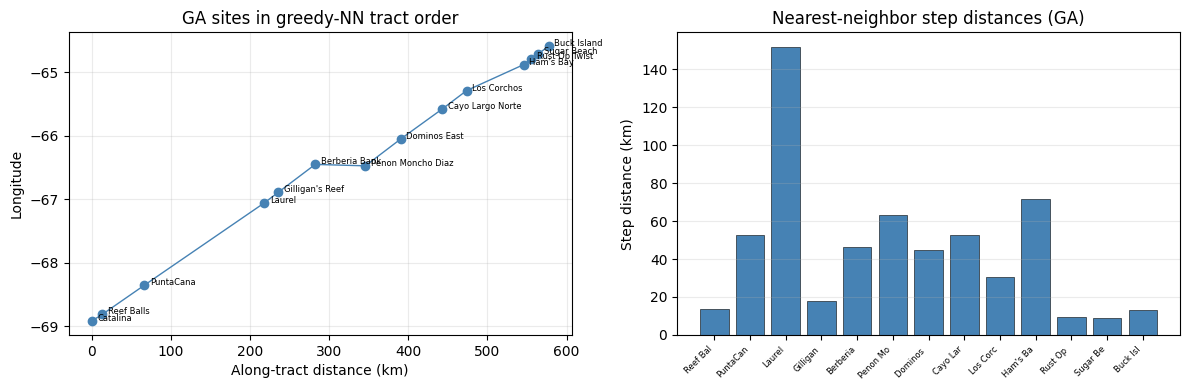

,site,tract_km,n_genets
0,Catalina,0.000000,17
1,Reef Balls,13.736069,6
2,PuntaCana,66.442707,28
3,Laurel,218.403585,17
4,Gilligan's Reef,236.150736,79
5,Berberia Bank,282.532330,8
6,Penon Moncho Diaz,345.966092,30
7,Dominos East,390.700427,6
8,Cayo Largo Norte,443.154347,24
9,Los Corchos,473.909192,19


In [26]:
# ── GA tract ordering visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: sites positioned along the tract (tract_km vs longitude)
ax = axes[0]
ax.plot(ga_sites_ordered["tract_km"], ga_sites_ordered["lon_median"],
        "o-", color="steelblue", ms=6, lw=1)
for _, _row in ga_sites_ordered.iterrows():
    ax.annotate(
        _row["site"],
        (_row["tract_km"], _row["lon_median"]),
        fontsize=6, xytext=(4, 0), textcoords="offset points",
    )
ax.set_xlabel("Along-tract distance (km)")
ax.set_ylabel("Longitude")
ax.set_title("GA sites in greedy-NN tract order")
ax.grid(True, alpha=0.25)

# right: nearest-neighbor step distances
_steps = ga_sites_ordered["tract_km"].diff().dropna()
ax2 = axes[1]
ax2.bar(range(len(_steps)), _steps.values, edgecolor="k", linewidth=0.4, color="steelblue")
ax2.set_xticks(range(len(_steps)))
ax2.set_xticklabels(
    [f"{ga_sites_ordered.iloc[i]['site'][:8]}" for i in range(1, len(ga_sites_ordered))],
    rotation=45, ha="right", fontsize=6,
)
ax2.set_ylabel("Step distance (km)")
ax2.set_title("Nearest-neighbor step distances (GA)")
ax2.grid(True, alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

ga_sites_ordered[["site", "tract_km", "n_genets"]]


In [27]:
# ── GA IBD plot aesthetics ────────────────────────────────────────────────────
IBD_MARKERS = {
    "within_region":  "^",
    "between_region": "o",
}

IBD_PAIR_COLORS = {
    "Cuba–Cuba":                              "#72B7B2",
    "Cuba–Dominican Republic":               "#8FBF8F",
    "Cuba–Jamaica":                          "#76A5AF",
    "Cuba–Puerto Rico":                      "#C2A5CF",
    "Cuba–USVI":                             "#86BCB6",
    "Dominican Republic–Dominican Republic": "#4C78A8",
    "Dominican Republic–Jamaica":            "#A0CBE8",
    "Dominican Republic–Puerto Rico":        "#F2A65A",
    "Dominican Republic–USVI":               "#54A24B",
    "Jamaica–Jamaica":                       "#ECA82C",
    "Jamaica–Puerto Rico":                   "#FFBE7D",
    "Jamaica–USVI":                          "#B6992D",
    "Puerto Rico–Puerto Rico":               "#E45756",
    "Puerto Rico–USVI":                      "#B279A2",
    "USVI–USVI":                             "#9D755D",
}

# report which pairs are present / missing
_present = set(ga_ibd_df["pair_group"].unique())
_missing = [k for k in IBD_PAIR_COLORS if k not in _present]
_unknown = [g for g in _present if g not in IBD_PAIR_COLORS]
if _missing: print(f"Not in data (ignored): {_missing}")
if _unknown: print(f"In data but no color assigned: {_unknown}")


Not in data (ignored): ['Cuba–Cuba', 'Cuba–Dominican Republic', 'Cuba–Jamaica', 'Cuba–Puerto Rico', 'Cuba–USVI', 'Dominican Republic–Jamaica', 'Jamaica–Jamaica', 'Jamaica–Puerto Rico', 'Jamaica–USVI']


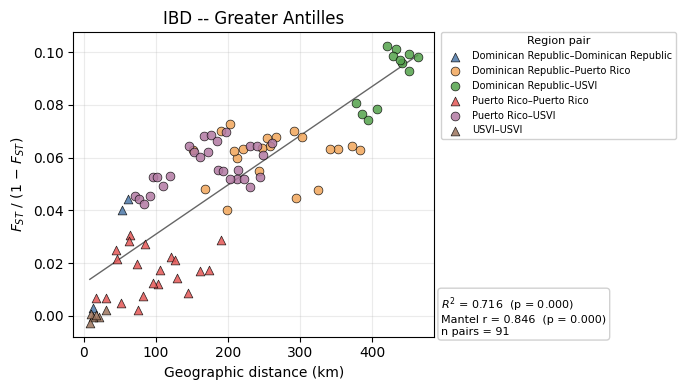

{'x_col': 'geo_dist_km',
 'n_pairs': 91,
 'slope': np.float64(0.0001869761038429871),
 'intercept': np.float64(0.012242487479370859),
 'ols_r2': np.float64(0.7159627442999091),
 'ols_p': np.float64(4.697940507762385e-26),
 'mantel_r': 0.8461458173978695,
 'mantel_p': 9.999000099990002e-05}

In [28]:
save_base = "/Users/kidelu001/awi-work/science/projects/apal_popgen/output/plots/ibd/ibd_grant"
ga_stats = plot_ibd(
    ga_ibd_df,
    figsize=(7,4),
    x_col="geo_dist_km",
    title="IBD -- Greater Antilles",
    hue_col="pair_group",
    pair_colors=IBD_PAIR_COLORS,
    markers=IBD_MARKERS,
    save_base=None,
)
ga_stats


---

*

*

*

---
## Florida panel

In [29]:
apal_wild

,affymetrix_id,species,mlg,region,region_sub,region_fix_reason,reef,lat_old,lon_old,lat_clean,lon_clean,coord_fix_reason,is_nursery,filtered_genets_n554,sexual_recruit,sample_id,user_specimen_id,perc_missing_data,perc_heterozygous,perc_acer,perc_apal,seq_facility,organization,Unnamed: 23,collection_date,subregion_ibd
0,121170171_(Axiom_AcropSNP)_K05.CEL,A.palmata,HG1491,Bahamas,Bahamas,NaN,AdelaineCay,22.17337,-75.70300,22.17337,-75.70300,NaN,False,True,NaN,A12725,9334,0.17,0.63,0.54,98.80,Eurofins,Penn State,NaN,1/13/08,Exclude
1,121170195_(Axiom_AcropSNP)_O05.CEL,A.palmata,HG1495,Bahamas,Bahamas,NaN,AdelaineCay,22.17337,-75.70300,22.17337,-75.70300,NaN,False,True,NaN,A12749,9345,0.20,0.64,0.67,98.63,Eurofins,Penn State,NaN,1/13/08,Exclude
2,121170183_(Axiom_AcropSNP)_M05.CEL,A.palmata,HG1498,Bahamas,Bahamas,NaN,AdelaineCay,22.17337,-75.70300,22.17337,-75.70300,NaN,False,True,NaN,A12737,9335,0.20,1.03,0.40,98.51,Eurofins,Penn State,NaN,1/13/08,Exclude
3,121166503_(Axiom_AcropSNP)_A05.CEL,A.palmata,HG1544,Bahamas,Bahamas,NaN,BlackBouy,23.80219,-76.14600,23.80219,-76.14600,NaN,False,True,NaN,A12761,1643,0.21,0.56,0.36,99.01,Eurofins,Penn State,NaN,2/3/03,Exclude
4,121166539_(Axiom_AcropSNP)_G05.CEL,A.palmata,HG1550,Bahamas,Bahamas,NaN,BlackBouy,23.80219,-76.14600,23.80219,-76.14600,NaN,False,True,NaN,A12797,1658,0.21,0.34,0.41,99.18,Eurofins,Penn State,NaN,2/3/03,Exclude
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2627,325318639_(Axiom_AcropSNP)_A05.CEL,A.palmata,HG2656,USVI,USVI,NaN,Sugar Beach,17.76005,-64.71513,17.76005,-64.71513,NaN,False,True,NaN,A16830,APAL628,1.29,1.28,0.54,97.48,EuroFins,The Nature Conservancy,NaN,10/9/25,GreaterAntilles
2628,325318637_(Axiom_AcropSNP)_M03.CEL,A.palmata,HG2629,USVI,USVI,NaN,Sugar Beach,17.76011,-64.71713,17.76011,-64.71713,NaN,False,False,NaN,A16828,APAL623,0.70,0.70,0.51,98.49,EuroFins,The Nature Conservancy,NaN,10/9/25,GreaterAntilles
2629,325318636_(Axiom_AcropSNP)_K03.CEL,A.palmata,HG2629,USVI,USVI,NaN,Sugar Beach,17.76018,-64.71717,17.76018,-64.71717,NaN,False,True,NaN,A16827,APAL622,0.79,0.75,0.52,98.40,EuroFins,The Nature Conservancy,NaN,10/9/25,GreaterAntilles
2630,325318638_(Axiom_AcropSNP)_O03.CEL,A.palmata,HG2652,USVI,USVI,NaN,Sugar Beach,17.76022,-64.71649,17.76022,-64.71649,NaN,False,True,NaN,A16829,APAL626,0.70,0.99,0.51,98.18,EuroFins,The Nature Conservancy,NaN,10/9/25,GreaterAntilles


In [30]:
# ── Florida site merge map ────────────────────────────────────────────────────
# Maps raw reef names from the metadata → canonical site labels.
# Names not present in this dict pass through unchanged (original reef name kept).
#
# Run the sanity check below first to see what names are in your data,
# then fill in / adjust as needed before running build_panel.

FL_SITE_MERGE_MAP = {
    # Sand Key
    "Sand Key":           "Sand Key",
    # Sand Island
    "Sand Island":        "Sand Island",
    "SI3":                "Sand Island",
    # Sambo Reef
    "Sambo":              "Sambo",
    # Elbow Reef
    "Elbow":              "Elbow",
    "EL2":                "Elbow",
    # Looe Key
    "Looe":               "Looe",
    # Biscayne Bay
    "Biscayne":           "Biscayne",
    # Conch Reef
    "Conch":              "Conch",
    "CRF":                "Conch",
    # Fowey Rocks
    "Fowey":              "Fowey",
    # French Reef
    "French":             "French Reef",
    "FR2":                "French Reef",
    # Grecian Rocks
    "Grecian":            "Grecian Rocks",
    "GR1":                "Grecian Rocks",
    # Horseshoe Reef
    "Horseshoe":          "Horseshoe",
    # Brewster Reef
    "Brew":               "Brewster",
    # Marker 3
    "Marker3":            "Marker3",
    "Marker 3":           "Marker3",
    # Ball Buoy
    "Ball Buoy":          "Ball Buoy",
    "Ball Paul":          "Ball Buoy",
    # Carysfort Reef
    "Carysfort":          "Carysfort",
    "CF2":                "Carysfort",
    # Molasses Reef
    "Molasses":           "Molasses",
    "ML3":                "Molasses",
    # Snapper Ledge
    "Snapledge":          "Snapper Ledge",
    "Snapper Ledge":      "Snapper Ledge",
    # Dry Rocks
    "KL4":                "Dry Rocks",
    "Dry Rocks":          "Dry Rocks",
    # Triple A
    "Triple A":           "Triple A",
    # Watson
    "Watson":             "Watson",
    # Turtle Rocks
    "Trtlrks":            "Turtle Rocks",
    "Turtle Rocks":       "Turtle Rocks",
    # Mote Marine
    "Mote":               "Mote",
}

# Sanity check: show any Florida reef names not covered by the map above
_fl_raw = apal_ibd.loc[apal_ibd[IBD_COL] == "Florida", SITE_COL].dropna().unique()
_unmapped = sorted(s for s in _fl_raw if s not in FL_SITE_MERGE_MAP)
if _unmapped:
    print(f"\u26a0  {len(_unmapped)} unmapped Florida reef name(s) — will keep original label:")
    for _s in _unmapped:
        print(f"   {repr(_s)}")
else:
    print("\u2713 All Florida reef names are covered by FL_SITE_MERGE_MAP.")


⚠  128 unmapped Florida reef name(s) — will keep original label:
   'AMAP'
   'Acropolis'
   'Allans Reef'
   "Amanda's Reef"
   'BB3'
   'BNP - BB'
   'Ball Buoy Ball Paul'
   'Ball Buoy North'
   'Ball Buoy Reef'
   'Ball Buoy South'
   'BallBuoy'
   'Between Pickles and Molasses'
   'Brewap'
   'Brewap West'
   'Brewster Reef'
   'Brewster West'
   "Brewster's Reef"
   'Broward County'
   'C. Pal'
   'Carysfort North'
   'Carysfort OP'
   'Carysfort Reef'
   'Carysfort Reef Key Largo'
   'Carysfort Reef South'
   'Carysfort South 1'
   'Carysfort South 2'
   'Cheetos'
   'Conch Reef'
   'Conch Reef not in SPA (CN1)'
   'ConchReef'
   'Cpal'
   'DR9'
   'Delta Shoal'
   'DryTortugas2'
   'ELBO'
   'East of Eastern Sambo'
   'Elbow OP'
   'Elbow Reef'
   'Elbow Reef OP'
   'Elbow SPA'
   'FLAQ'
   'FREN'
   'FWC Ball Buoy'
   'Fowey South'
   'French Reef'
   'Grecian Rocks'
   'Horseshoe Mooring'
   'Horseshoe North'
   'Horseshoe Reef'
   'Horseshoe Reef - Key Largo'
   'Horseshoe R

In [31]:
# ── Florida sample df + site counts (harmonized names) ──────────────────────
florida_df = apal_wild.loc[
    apal_wild["subregion_ibd"] == "Florida"
].copy().reset_index(drop=True)

# apply name harmonization so site counts reflect clean names
florida_df["site_harmonized"] = florida_df[REEF_COL].map(
    lambda x: FL_SITE_MERGE_MAP.get(x, x)
)

fl_site_counts = (
    florida_df.groupby([SUBREGION_COL, "site_harmonized"], dropna=False)
    .agg(
        n_genets=(MLG_COL, lambda s: s.nunique(dropna=True)),
        lat_clean=(LAT_COL, "median"),
        lon_clean=(LON_COL, "median"),
    )
    .reset_index()
    .sort_values(["n_genets", SUBREGION_COL], ascending=[False, True])
    .reset_index(drop=True)
)
fl_site_counts


,region_sub,site_harmonized,n_genets,lat_clean,lon_clean
0,Florida,Unknown,103,24.662919,-81.007571
1,Florida,The Reef Institute,90,25.227530,-80.207300
2,Florida,Looe Key Bouys 10-11,44,24.545850,-81.405100
3,Florida,Elbow Reef,33,25.142911,-80.258254
4,Florida,North Dry Rocks OP,27,25.129900,-80.293800
5,Florida,Key Biscayne A3,24,25.676555,-80.098518
6,Florida,Looe Key,18,24.546930,-81.407700
7,Florida,Sombrero Reef,18,24.625820,-81.110400
8,Florida,Key Biscayne C2,16,25.676555,-80.098518
9,Florida,French Reef,14,25.034950,-80.349020


In [32]:
# Sanity check: after is_nursery filter, florida_df should have no True rows.
# NaN rows ARE included (treated as wild by fillna(False) above).
# If NaN count is large, consider revisiting metadata or expanding NURSERY_SITE_EXCLUDE.
florida_df.groupby("is_nursery", dropna=False).size()


is_nursery
False    1453
dtype: int64

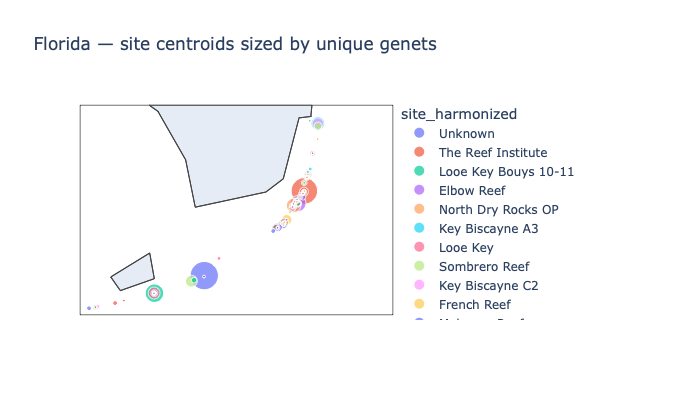

In [33]:
# ── Florida site map ─────────────────────────────────────────────────────────
fig = px.scatter_geo(
    fl_site_counts,
    lat="lat_clean",
    lon="lon_clean",
    color="site_harmonized",
    size="n_genets",
    hover_name=SUBREGION_COL,
    hover_data=[SUBREGION_COL, "site_harmonized", "n_genets"],
    title="Florida — site centroids sized by unique genets",
)
fig.update_geos(
    scope="world", projection_type="natural earth",
    showcountries=True, showcoastlines=True,
    lataxis_range=[24.4, 25.8], lonaxis_range=[-82.0, -79.5],
)
fig.update_layout(height=400)
fig.show()


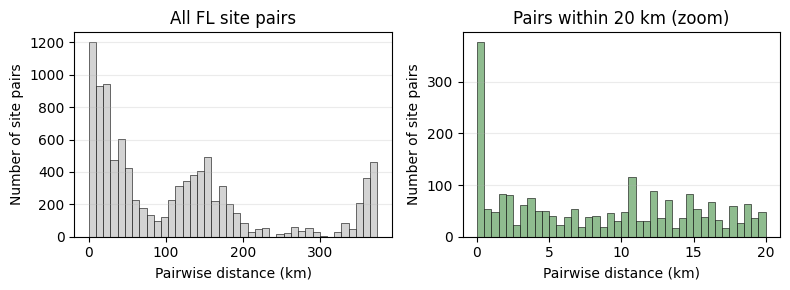

Candidate proximity merges (≤ 10 km, same subregion):


In [34]:
# ── FL site proximity exploration ────────────────────────────────────────────
# Build site centroids from harmonized names so clustering works on clean labels.

fl_site_coords_raw = (
    florida_df.groupby("site_harmonized")
    .agg(
        lat_median=(LAT_COL,       "median"),
        lon_median=(LON_COL,       "median"),
        n_genets  =(MLG_COL,       "nunique"),
        subregion =(SUBREGION_COL, "first"),
    )
    .reset_index()
    .rename(columns={"site_harmonized": "site"})
)

# pairwise distances
_fl_sites = fl_site_coords_raw["site"].tolist()
_fl_dist_rows = []
for _i, _s1 in enumerate(_fl_sites):
    for _j, _s2 in enumerate(_fl_sites):
        if _j <= _i:
            continue
        _r1 = fl_site_coords_raw.loc[fl_site_coords_raw["site"] == _s1].iloc[0]
        _r2 = fl_site_coords_raw.loc[fl_site_coords_raw["site"] == _s2].iloc[0]
        _d  = haversine_km(_r1["lat_median"], _r1["lon_median"],
                           _r2["lat_median"], _r2["lon_median"])
        _fl_dist_rows.append({
            "site1": _s1, "n1": int(_r1["n_genets"]),
            "site2": _s2, "n2": int(_r2["n_genets"]),
            "sub1":  _r1["subregion"],
            "sub2":  _r2["subregion"],
            "dist_km": _d,
        })

fl_dist_df = pd.DataFrame(_fl_dist_rows)

# distance distribution plots
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].hist(fl_dist_df["dist_km"], bins=40, edgecolor="k", linewidth=0.4, color="lightgrey")
axes[0].set_xlabel("Pairwise distance (km)")
axes[0].set_ylabel("Number of site pairs")
axes[0].set_title("All FL site pairs")
axes[0].grid(True, alpha=0.25, axis="y")

_fl_close = fl_dist_df[fl_dist_df["dist_km"] <= 20]
axes[1].hist(_fl_close["dist_km"], bins=40, edgecolor="k", linewidth=0.4, color="darkseagreen")
axes[1].set_xlabel("Pairwise distance (km)")
axes[1].set_ylabel("Number of site pairs")
axes[1].set_title("Pairs within 20 km (zoom)")
axes[1].grid(True, alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

# candidate merges
FL_PROX_THRESH_KM = 10  # adjust after inspecting histogram

fl_merge_candidates = fl_dist_df[
    (fl_dist_df["sub1"] == fl_dist_df["sub2"]) &
    (fl_dist_df["dist_km"] <= FL_PROX_THRESH_KM)
].sort_values("dist_km").reset_index(drop=True)

print(f"Candidate proximity merges (≤ {FL_PROX_THRESH_KM} km, same subregion):")


In [35]:
# ── Assign Upper / Middle / Lower Keys section to each FL site ──────────────
# Reference centroids from Manzello 2012 (doi:10.1371/journal.pone.0041715)

keys_refs = pd.DataFrame({
    "keys_section": ["Upper Keys", "Upper Keys",
                     "Middle Keys", "Middle Keys",
                     "Lower Keys",  "Lower Keys"],
    "lat": [24.93898, 24.94650, 24.81216, 24.76724, 24.59723, 24.55141],
    "lon": [-80.56272, -80.50207, -80.76075, -80.75227, -81.45505, -81.40251],
})

keys_section_centroids = (
    keys_refs.groupby("keys_section", as_index=False)
    .agg(lat_ref=("lat", "mean"), lon_ref=("lon", "mean"))
)

def assign_keys_section(lat, lon, ref_df=keys_section_centroids):
    dists = ref_df.apply(
        lambda r: haversine_km(lat, lon, r["lat_ref"], r["lon_ref"]),
        axis=1,
    )
    return ref_df.loc[dists.idxmin(), "keys_section"]

# add to fl_site_coords_raw (already has lat_median / lon_median)
fl_site_coords_raw["keys_section"] = fl_site_coords_raw.apply(
    lambda r: assign_keys_section(r["lat_median"], r["lon_median"]),
    axis=1,
)

fl_site_coords_raw[['site', 'keys_section', 'lat_median', 'lon_median', 'n_genets']]\
    .sort_values(['keys_section', 'lon_median'])


,site,keys_section,lat_median,lon_median,n_genets
1,Acropolis,Lower Keys,24.680200,-82.891200,1
37,DryTortugas2,Lower Keys,24.620900,-82.867500,1
138,Western Dry Rocks,Lower Keys,24.445335,-81.927200,3
119,Sand Key,Lower Keys,24.452305,-81.877283,5
120,Sand Key - N. of Buoy 3,Lower Keys,24.452760,-81.875530,1
121,Sand Key N of Buoy 3,Lower Keys,24.452760,-81.875530,2
115,RockKey,Lower Keys,24.456020,-81.859600,3
139,Western Sambo,Lower Keys,24.479870,-81.718700,3
111,Patch east of Eastern Sambo,Lower Keys,24.495870,-81.649030,1
141,patch E. of Eastern Sambo,Lower Keys,24.495870,-81.649030,1


In [36]:
fl_merge_candidates.sort_values(
    ["sub1", "dist_km"], ascending=[True, True]
)[["sub1", "site1", "n1", "site2", "n2", "dist_km"]].reset_index(drop=True)


,sub1,site1,n1,site2,n2,dist_km
0,Florida,FLAQ,3,MD1,1,0.000000
1,Florida,ELBO,1,Mote 1,4,0.000000
2,Florida,ELBO,1,Kuffner,2,0.000000
3,Florida,ELBO,1,FREN,1,0.000000
4,Florida,ELBO,1,FLAQ,3,0.000000
...,...,...,...,...,...,...
1240,Florida,Ball Buoy Reef,1,Carysfort North,1,9.966394
1241,Florida,Ball Buoy Reef,1,The Reef Institute,90,9.966394
1242,Florida,Elbow Reef OP,6,North Carysfort Reef,2,9.992162
1243,Florida,Elbow OP,6,North Carysfort Reef,2,9.993472


In [37]:
# ── long-format df for FL candidate maps ─────────────────────────────────────
_fl_pair_rows = []
for _idx, _row in fl_merge_candidates.iterrows():
    _label = f"{_row['site1']} ↔ {_row['site2']}"
    for _site, _partner in ((_row['site1'], _row['site2']),
                             (_row['site2'], _row['site1'])):
        _info = fl_site_coords_raw.loc[fl_site_coords_raw['site'] == _site].iloc[0]
        _fl_pair_rows.append({
            'site':       _site,
            'subregion':  _row['sub1'],
            'pair_label': _label,
            'partner':    _partner,
            'dist_km':    round(float(_row['dist_km']), 1),
            'n_genets':   int(_info['n_genets']),
            'lat':        _info['lat_median'],
            'lon':        _info['lon_median'],
        })

fl_merge_plot_df = (
    pd.DataFrame(_fl_pair_rows)
    .drop_duplicates(subset=['site', 'pair_label'])
    .reset_index(drop=True)
)
print(f"{len(fl_merge_plot_df)} rows | {fl_merge_plot_df['pair_label'].nunique()} candidate pairs")
fl_merge_plot_df


2490 rows | 1245 candidate pairs


,site,subregion,pair_label,partner,dist_km,n_genets,lat,lon
0,FLAQ,Florida,FLAQ ↔ MD1,MD1,0.0,3,27.778847,-82.404503
1,MD1,Florida,FLAQ ↔ MD1,FLAQ,0.0,1,27.778847,-82.404503
2,ELBO,Florida,ELBO ↔ Mote 1,Mote 1,0.0,1,27.778847,-82.404503
3,Mote 1,Florida,ELBO ↔ Mote 1,ELBO,0.0,4,27.778847,-82.404503
4,ELBO,Florida,ELBO ↔ Kuffner,Kuffner,0.0,1,27.778847,-82.404503
...,...,...,...,...,...,...,...,...
2485,North Carysfort Reef,Florida,Elbow Reef OP ↔ North Carysfort Reef,Elbow Reef OP,10.0,2,25.222266,-80.210324
2486,Elbow OP,Florida,Elbow OP ↔ North Carysfort Reef,North Carysfort Reef,10.0,6,25.143383,-80.257913
2487,North Carysfort Reef,Florida,Elbow OP ↔ North Carysfort Reef,Elbow OP,10.0,2,25.222266,-80.210324
2488,Carysfort,Florida,Carysfort ↔ Elbow Reef,Elbow Reef,10.0,1,25.221790,-80.210600


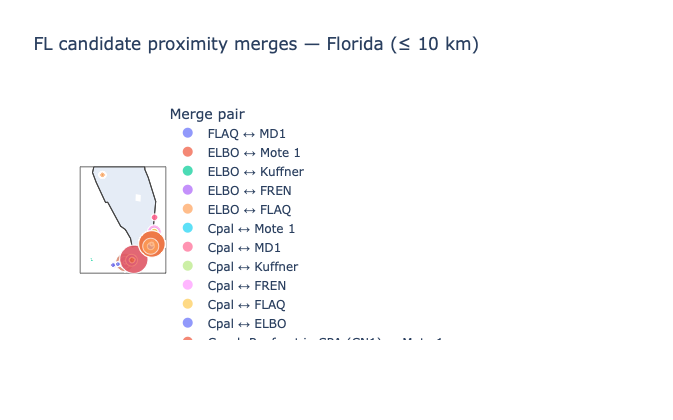

In [38]:
# ── FL candidate maps, one figure per subregion ──────────────────────────────
_PAD_LAT, _PAD_LON = 0.3, 0.5

for _sub in sorted(fl_merge_plot_df['subregion'].unique()):
    _sub_df = fl_merge_plot_df[fl_merge_plot_df['subregion'] == _sub]
    _lat_range = [_sub_df['lat'].min() - _PAD_LAT, _sub_df['lat'].max() + _PAD_LAT]
    _lon_range = [_sub_df['lon'].min() - _PAD_LON, _sub_df['lon'].max() + _PAD_LON]
    fig = px.scatter_geo(
        _sub_df,
        lat='lat', lon='lon', color='pair_label', size='n_genets',
        hover_name='site',
        hover_data={'n_genets': True, 'partner': True, 'dist_km': True,
                    'lat': False, 'lon': False},
        labels={'pair_label': 'Merge pair', 'n_genets': 'Genets',
                'partner': 'Merge partner', 'dist_km': 'Distance (km)'},
        title=f'FL candidate proximity merges — {_sub} (≤ {FL_PROX_THRESH_KM} km)',
    )
    fig.update_geos(
        scope='world', projection_type='natural earth',
        showcountries=True, showcoastlines=True,
        lataxis_range=_lat_range, lonaxis_range=_lon_range,
    )
    fig.update_layout(height=420)
    fig.show()


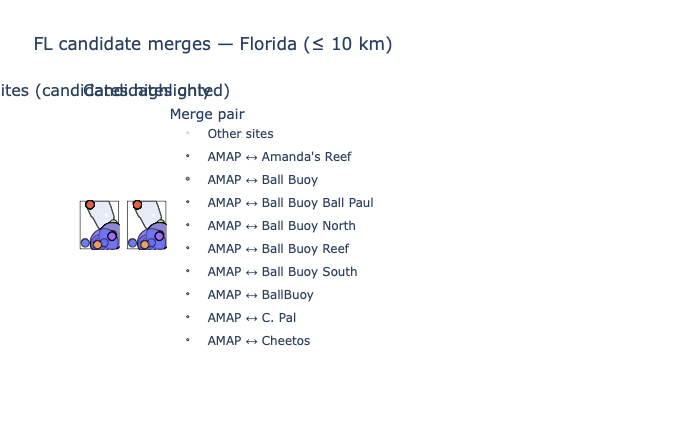

In [39]:
# ── FL candidate maps: all sites + candidates side by side ───────────────────
_max_genets_fl = fl_site_coords_raw['n_genets'].max()
_sizeref_fl    = 2 * _max_genets_fl / (28 ** 2)
_PAD_LAT, _PAD_LON = 0.3, 0.5

for _sub in sorted(fl_merge_plot_df['subregion'].unique()):
    _cand_sub   = fl_merge_plot_df[fl_merge_plot_df['subregion'] == _sub]
    _all_sub    = fl_site_coords_raw[fl_site_coords_raw['subregion'] == _sub]
    _cand_sites = set(_cand_sub['site'])
    _non_cand   = _all_sub[~_all_sub['site'].isin(_cand_sites)]
    _pairs      = sorted(_cand_sub['pair_label'].unique())
    _clr_cycle  = px.colors.qualitative.Plotly
    _pair_color = {p: _clr_cycle[i % len(_clr_cycle)] for i, p in enumerate(_pairs)}
    _lat_range  = [_all_sub['lat_median'].min() - _PAD_LAT,
                   _all_sub['lat_median'].max() + _PAD_LAT]
    _lon_range  = [_all_sub['lon_median'].min() - _PAD_LON,
                   _all_sub['lon_median'].max() + _PAD_LON]
    _geo_cfg = dict(scope='world', projection_type='natural earth',
                    showcountries=True, showcoastlines=True,
                    lataxis_range=_lat_range, lonaxis_range=_lon_range)
    fig = make_subplots(rows=1, cols=2,
                        specs=[[{'type': 'geo'}, {'type': 'geo'}]],
                        subplot_titles=['All sites (candidates highlighted)', 'Candidates only'])
    if len(_non_cand):
        fig.add_trace(go.Scattergeo(
            lat=_non_cand['lat_median'], lon=_non_cand['lon_median'], mode='markers',
            marker=dict(size=_non_cand['n_genets'], sizemode='area',
                        sizeref=_sizeref_fl, sizemin=4, color='lightgrey',
                        line=dict(width=0.5, color='darkgrey')),
            text=_non_cand['site'], customdata=_non_cand['n_genets'].values,
            hovertemplate='<b>%{text}</b><br>Genets: %{customdata}<extra>other site</extra>',
            name='Other sites', legendgroup='other', showlegend=True,
        ), row=1, col=1)
    def _fl_pair_traces(col, show_legend):
        for _pair in _pairs:
            _pdf = _cand_sub[_cand_sub['pair_label'] == _pair]
            fig.add_trace(go.Scattergeo(
                lat=_pdf['lat'], lon=_pdf['lon'], mode='markers',
                marker=dict(size=_pdf['n_genets'], sizemode='area',
                            sizeref=_sizeref_fl, sizemin=4, color=_pair_color[_pair],
                            line=dict(width=0.8, color='black')),
                text=_pdf['site'],
                customdata=_pdf[['n_genets', 'partner', 'dist_km']].values,
                hovertemplate=('<b>%{text}</b><br>Genets: %{customdata[0]}<br>'
                               'Merge partner: %{customdata[1]}<br>'
                               'Distance: %{customdata[2]} km<extra></extra>'),
                name=_pair, legendgroup=_pair, showlegend=show_legend,
            ), row=1, col=col)
    _fl_pair_traces(col=1, show_legend=True)
    _fl_pair_traces(col=2, show_legend=False)
    fig.update_layout(geo=_geo_cfg, geo2=_geo_cfg,
                      title_text=f'FL candidate merges — {_sub} (≤ {FL_PROX_THRESH_KM} km)',
                      height=430, width=980,
                      legend=dict(title='Merge pair', tracegroupgap=4))
    fig.show()


In [40]:
# ── FL complete-linkage clustering → FL_PROX_MERGE_MAP ───────────────────────
_fl_site_list = fl_site_coords_raw['site'].tolist()
_fl_n         = len(_fl_site_list)
_fl_dist_mat  = np.zeros((_fl_n, _fl_n))

for _i in range(_fl_n):
    for _j in range(_i + 1, _fl_n):
        _r1, _r2 = fl_site_coords_raw.iloc[_i], fl_site_coords_raw.iloc[_j]
        _d = haversine_km(_r1['lat_median'], _r1['lon_median'],
                          _r2['lat_median'], _r2['lon_median'])
        _fl_dist_mat[_i, _j] = _fl_dist_mat[_j, _i] = _d

_fl_Z      = linkage(squareform(_fl_dist_mat), method='complete')
_fl_labels = fcluster(_fl_Z, t=FL_PROX_THRESH_KM, criterion='distance')
fl_site_coords_raw['prox_cluster'] = _fl_labels

_fl_cl_sizes   = fl_site_coords_raw.groupby('prox_cluster')['site'].count()
_fl_multi_cls  = _fl_cl_sizes[_fl_cl_sizes > 1].index

FL_PROX_MERGE_MAP = {}
for _cl in _fl_multi_cls:
    _members   = fl_site_coords_raw.loc[
        fl_site_coords_raw['prox_cluster'] == _cl, 'site'].tolist()
    _canonical = fl_site_coords_raw.loc[
        fl_site_coords_raw['site'].isin(_members)
    ].sort_values('n_genets', ascending=False).iloc[0]['site']
    for _s in _members:
        FL_PROX_MERGE_MAP[_s] = _canonical

print(f'{len(_fl_multi_cls)} proximity clusters → {len(FL_PROX_MERGE_MAP)} sites remapped')
FL_PROX_MERGE_MAP


18 proximity clusters → 141 sites remapped


{'BNP - BB': 'BNP - BB',
 'Conch Reef not in SPA (CN1)': 'BNP - BB',
 'Cpal': 'BNP - BB',
 'ELBO': 'BNP - BB',
 'FLAQ': 'BNP - BB',
 'FREN': 'BNP - BB',
 'Kuffner': 'BNP - BB',
 'MD1': 'BNP - BB',
 'Mote 1': 'BNP - BB',
 'AMAP': 'Key Biscayne A2',
 "Amanda's Reef": 'Key Biscayne A2',
 'Ball Buoy': 'Key Biscayne A2',
 'Ball Buoy Ball Paul': 'Key Biscayne A2',
 'Ball Buoy North': 'Key Biscayne A2',
 'Ball Buoy Reef': 'Key Biscayne A2',
 'Ball Buoy South': 'Key Biscayne A2',
 'BallBuoy': 'Key Biscayne A2',
 'C. Pal': 'Key Biscayne A2',
 'Cheetos': 'Key Biscayne A2',
 'DR9': 'Key Biscayne A2',
 'FWC Ball Buoy': 'Key Biscayne A2',
 'Key Biscayne A2': 'Key Biscayne A2',
 'Key Biscayne B5': 'Key Biscayne A2',
 'Lab': 'Key Biscayne A2',
 'Laura Palmata': 'Key Biscayne A2',
 'Marker3': 'Key Biscayne A2',
 'Mote 2': 'Key Biscayne A2',
 'UM valentines (Ledbury)': 'Key Biscayne A2',
 'TRTLRKS': 'Turtle Rocks',
 'Turtle Rocks': 'Turtle Rocks',
 'Carysfort': 'The Reef Institute',
 'Carysfort North':

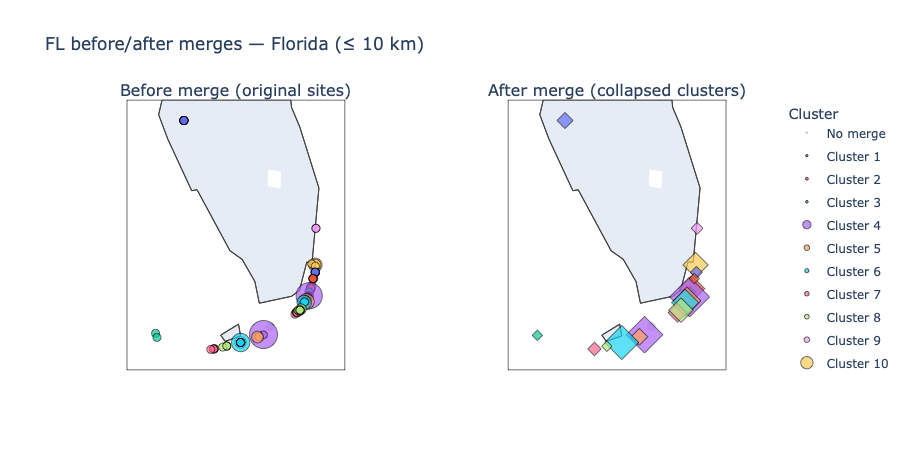

In [47]:
# ── FL before / after proximity merge maps ───────────────────────────────────
_max_genets_fl = fl_site_coords_raw['n_genets'].max()
_sizeref_fl    = 2 * _max_genets_fl / (28 ** 2)
_PAD_LAT, _PAD_LON = 0.3, 0.5

for _sub in sorted(fl_site_coords_raw['subregion'].unique()):
    _sub_df    = fl_site_coords_raw[fl_site_coords_raw['subregion'] == _sub].copy()
    _cl_sizes  = _sub_df.groupby('prox_cluster')['site'].count()
    _multi_cls = sorted(_cl_sizes[_cl_sizes > 1].index)
    _single_cl = set(_cl_sizes[_cl_sizes == 1].index)
    _singletons = _sub_df[_sub_df['prox_cluster'].isin(_single_cl)]
    _clr_cycle  = px.colors.qualitative.Plotly
    _cl_color   = {cl: _clr_cycle[i % len(_clr_cycle)] for i, cl in enumerate(_multi_cls)}
    _lat_range  = [_sub_df['lat_median'].min() - _PAD_LAT,
                   _sub_df['lat_median'].max() + _PAD_LAT]
    _lon_range  = [_sub_df['lon_median'].min() - _PAD_LON,
                   _sub_df['lon_median'].max() + _PAD_LON]
    _geo_cfg = dict(scope='world', projection_type='natural earth',
                    showcountries=True, showcoastlines=True,
                    lataxis_range=_lat_range, lonaxis_range=_lon_range)
    fig = make_subplots(rows=1, cols=2,
                        specs=[[{'type': 'geo'}, {'type': 'geo'}]],
                        subplot_titles=['Before merge (original sites)',
                                        'After merge (collapsed clusters)'])
    def _fl_singleton_trace(col, show_legend):
        fig.add_trace(go.Scattergeo(
            lat=_singletons['lat_median'], lon=_singletons['lon_median'], mode='markers',
            marker=dict(size=_singletons['n_genets'], sizemode='area',
                        sizeref=_sizeref_fl, sizemin=4, color='lightgrey',
                        line=dict(width=0.5, color='darkgrey')),
            text=_singletons['site'], customdata=_singletons['n_genets'].values,
            hovertemplate='<b>%{text}</b><br>Genets: %{customdata}<extra>no merge</extra>',
            name='No merge', legendgroup='singleton', showlegend=show_legend,
        ), row=1, col=col)
    _fl_singleton_trace(col=1, show_legend=True)
    _fl_singleton_trace(col=2, show_legend=False)
    for _cl in _multi_cls:
        _cl_df   = _sub_df[_sub_df['prox_cluster'] == _cl]
        _cl_name = f'Cluster {_cl}'
        fig.add_trace(go.Scattergeo(
            lat=_cl_df['lat_median'], lon=_cl_df['lon_median'], mode='markers',
            marker=dict(size=_cl_df['n_genets'], sizemode='area',
                        sizeref=_sizeref_fl, sizemin=4, color=_cl_color[_cl],
                        line=dict(width=0.8, color='black')),
            text=_cl_df['site'], customdata=_cl_df['n_genets'].values,
            hovertemplate='<b>%{text}</b><br>Genets: %{customdata}<extra>' + _cl_name + '</extra>',
            name=_cl_name, legendgroup=_cl_name, showlegend=True,
        ), row=1, col=1)
    for _cl in _multi_cls:
        _cl_df     = _sub_df[_sub_df['prox_cluster'] == _cl]
        _canonical = FL_PROX_MERGE_MAP[_cl_df.iloc[0]['site']]
        _total_n   = int(_cl_df['n_genets'].sum())
        _members   = ', '.join(_cl_df['site'].tolist())
        _cl_name   = f'Cluster {_cl}'
        fig.add_trace(go.Scattergeo(
            lat=[_cl_df['lat_median'].mean()], lon=[_cl_df['lon_median'].mean()],
            mode='markers',
            marker=dict(size=[_total_n], sizemode='area', sizeref=_sizeref_fl, sizemin=4,
                        color=_cl_color[_cl], line=dict(width=0.8, color='black'),
                        symbol='diamond'),
            text=[_canonical], customdata=[[_total_n, len(_cl_df), _members]],
            hovertemplate=('<b>%{text}</b> (merged)<br>Total genets: %{customdata[0]}<br>'
                           'Sites merged: %{customdata[1]}<br>Members: %{customdata[2]}'
                           '<extra></extra>'),
            name=_cl_name, legendgroup=_cl_name, showlegend=False,
        ), row=1, col=2)
    fig.update_layout(geo=_geo_cfg, geo2=_geo_cfg,
                      title_text=f'FL before/after merges — {_sub} (≤ {FL_PROX_THRESH_KM} km)',
                      height=450, width=980,
                      legend=dict(title='Cluster', tracegroupgap=4))
    fig.show()


In [41]:
# ── FL_COMBINED_MAP: name harmonization + proximity merges ───────────────────
# Chains FL_SITE_MERGE_MAP (raw code → canonical name) with
# FL_PROX_MERGE_MAP (canonical name → merged canonical name).
# Pass this as site_merge_map to build_panel.

FL_COMBINED_MAP = {}
# harmonize all known raw names, then apply proximity merge
for _raw, _harmonized in FL_SITE_MERGE_MAP.items():
    FL_COMBINED_MAP[_raw] = FL_PROX_MERGE_MAP.get(_harmonized, _harmonized)
# add any harmonized names not covered by FL_SITE_MERGE_MAP
for _site, _merged in FL_PROX_MERGE_MAP.items():
    if _site not in FL_COMBINED_MAP:
        FL_COMBINED_MAP[_site] = _merged

print(f'FL_COMBINED_MAP: {len(FL_COMBINED_MAP)} raw names → '
      f'{len(set(FL_COMBINED_MAP.values()))} canonical sites')
FL_COMBINED_MAP


FL_COMBINED_MAP: 162 raw names → 24 canonical sites


{'Sand Key': 'Sand Key',
 'Sand Island': 'French Reef',
 'SI3': 'French Reef',
 'Sambo': 'Sambo',
 'Elbow': 'Elbow Reef',
 'EL2': 'Elbow Reef',
 'Looe': 'Looe',
 'Biscayne': 'Biscayne',
 'Conch': 'Pickles Reef',
 'CRF': 'Pickles Reef',
 'Fowey': "Brewster's Reef",
 'French': 'French Reef',
 'FR2': 'French Reef',
 'Grecian': 'North Dry Rocks OP',
 'GR1': 'North Dry Rocks OP',
 'Horseshoe': 'North Dry Rocks OP',
 'Brew': "Brewster's Reef",
 'Marker3': 'Key Biscayne A2',
 'Marker 3': 'Key Biscayne A2',
 'Ball Buoy': 'Key Biscayne A2',
 'Ball Paul': 'Key Biscayne A2',
 'Carysfort': 'The Reef Institute',
 'CF2': 'The Reef Institute',
 'Molasses': 'French Reef',
 'ML3': 'French Reef',
 'Snapledge': 'Pickles Reef',
 'Snapper Ledge': 'Pickles Reef',
 'KL4': 'Dry Rocks',
 'Dry Rocks': 'Dry Rocks',
 'Triple A': 'Elbow Reef',
 'Watson': 'Watson',
 'Trtlrks': 'Turtle Rocks',
 'Turtle Rocks': 'Turtle Rocks',
 'Mote': 'Mote',
 'BNP - BB': 'BNP - BB',
 'Conch Reef not in SPA (CN1)': 'BNP - BB',
 'Cpa

In [42]:
fl_panel, fl_sites, fl_gta = build_panel(
    apal_ibd, gt,
    subregion="Florida",
    site_merge_map=FL_COMBINED_MAP,
)

print(f"{fl_panel['site_merged'].nunique()} sites | {fl_panel[MLG_COL].nunique()} genets")
fl_sites.sort_values('lon_median')


11 sites | 169 genets


,site,lat_median,lon_median,n_genets
7,Sand Key,24.452350,-81.877200,11
3,Looe Key Bouys 10-11,24.546930,-81.407700,11
8,Sombrero Reef,24.625820,-81.110400,13
10,Unknown,24.662919,-81.007571,11
6,Pickles Reef,24.984570,-80.418316,11
1,French Reef,25.033682,-80.349500,30
5,North Dry Rocks OP,25.122875,-80.298112,22
0,Elbow Reef,25.143915,-80.258242,22
9,The Reef Institute,25.215232,-80.214966,22
2,Key Biscayne A2,25.317410,-80.185200,11


In [43]:
fl_fst_df = compute_pairwise_fst(fl_panel, fl_gta)
print(f"{len(fl_fst_df)} site pairs | FST range: "
      f"{fl_fst_df['fst'].min():.4f} – {fl_fst_df['fst'].max():.4f}")
fl_fst_df.head()

55 site pairs | FST range: -0.0008 – 0.0485


,site1,site2,fst,n_loci
0,Elbow Reef,French Reef,0.001238,3494
1,Elbow Reef,Key Biscayne A2,0.014566,3463
2,Elbow Reef,Looe Key Bouys 10-11,0.007836,3498
3,Elbow Reef,NOVA,0.018078,3436
4,Elbow Reef,North Dry Rocks OP,-0.000753,3495


In [44]:
fl_sites_ordered = order_sites_greedy_nn(fl_sites)

# Keys section (Upper / Middle / Lower) per merged site
# assigned by nearest Manzello 2012 centroid; used for IBD pair coloring
fl_site_region = (
    fl_site_coords_raw.set_index("site")["keys_section"]
    .to_dict()
)

fl_ibd_df = build_ibd_df(fl_fst_df, fl_sites_ordered, site_region=fl_site_region)
fl_ibd_df.head()


,site1,site2,fst,n_loci,linearized_fst,geo_dist_km,along_tract_km,pair_group,pair_type
0,Elbow Reef,French Reef,0.001238,3494,0.001240,15.319811,15.832584,Upper Keys–Upper Keys,within
1,Elbow Reef,Key Biscayne A2,0.014566,3463,0.014782,20.643487,20.796519,Upper Keys–Upper Keys,within
2,Elbow Reef,Looe Key Bouys 10-11,0.007836,3498,0.007898,133.635852,136.550303,Lower Keys–Upper Keys,between
3,Elbow Reef,NOVA,0.018078,3436,0.018411,119.919692,120.666853,Upper Keys–Upper Keys,within
4,Elbow Reef,North Dry Rocks OP,-0.000753,3495,-0.000752,4.645633,4.645633,Upper Keys–Upper Keys,within


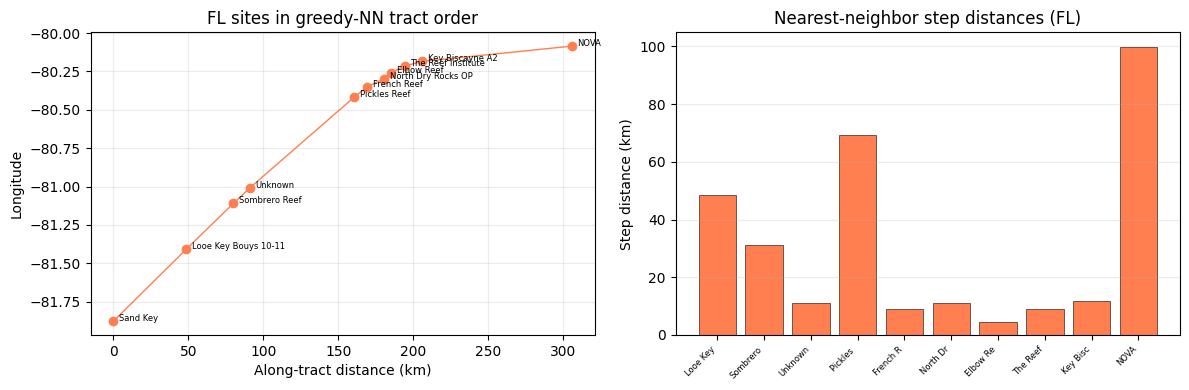

,site,tract_km,n_genets
0,Sand Key,0.000000,11
1,Looe Key Bouys 10-11,48.655745,11
2,Sombrero Reef,79.970530,13
3,Unknown,91.151849,11
4,Pickles Reef,160.546741,11
5,French Reef,169.373465,30
6,North Dry Rocks OP,180.560415,22
7,Elbow Reef,185.206049,22
8,The Reef Institute,194.253289,22
9,Key Biscayne A2,206.002568,11


In [45]:
# ── FL tract ordering visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: sites along the tract
ax = axes[0]
ax.plot(fl_sites_ordered["tract_km"], fl_sites_ordered["lon_median"],
        "o-", color="coral", ms=6, lw=1)
for _, _row in fl_sites_ordered.iterrows():
    ax.annotate(
        _row["site"],
        (_row["tract_km"], _row["lon_median"]),
        fontsize=6, xytext=(4, 0), textcoords="offset points",
    )
ax.set_xlabel("Along-tract distance (km)")
ax.set_ylabel("Longitude")
ax.set_title("FL sites in greedy-NN tract order")
ax.grid(True, alpha=0.25)

# right: nearest-neighbor step distances
_steps = fl_sites_ordered["tract_km"].diff().dropna()
ax2 = axes[1]
ax2.bar(range(len(_steps)), _steps.values, edgecolor="k", linewidth=0.4, color="coral")
ax2.set_xticks(range(len(_steps)))
ax2.set_xticklabels(
    [f"{fl_sites_ordered.iloc[i]['site'][:8]}" for i in range(1, len(fl_sites_ordered))],
    rotation=45, ha="right", fontsize=6,
)
ax2.set_ylabel("Step distance (km)")
ax2.set_title("Nearest-neighbor step distances (FL)")
ax2.grid(True, alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

fl_sites_ordered[["site", "tract_km", "n_genets"]]


In [46]:
# ── FL IBD plot aesthetics ───────────────────────────────────────────────────
# pair_group labels are alphabetically sorted Keys section pairs

FL_PAIR_COLORS = {
    "Lower Keys–Lower Keys":   "#4C78A8",   # blue
    "Lower Keys–Middle Keys":  "#72B7B2",   # teal
    "Lower Keys–Upper Keys":   "#B6992D",   # olive
    "Middle Keys–Middle Keys": "#54A24B",   # green
    "Middle Keys–Upper Keys":  "#F2A65A",   # soft orange
    "Upper Keys–Upper Keys":   "#E45756",   # red-orange
}

_fl_present = set(fl_ibd_df['pair_group'].unique())
_fl_missing = [k for k in FL_PAIR_COLORS if k not in _fl_present]
_fl_unknown = [g for g in _fl_present if g not in FL_PAIR_COLORS]
if _fl_missing: print(f'Not in data (ignored): {_fl_missing}')
if _fl_unknown: print(f'In data but no color assigned: {_fl_unknown}')


Not in data (ignored): ['Middle Keys–Middle Keys']


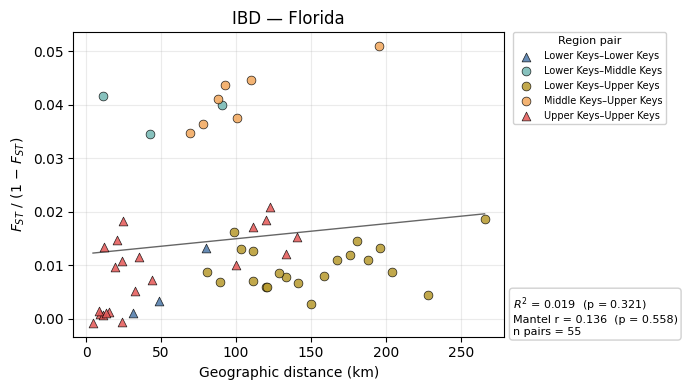

{'x_col': 'geo_dist_km',
 'n_pairs': 55,
 'slope': np.float64(2.805733598570249e-05),
 'intercept': np.float64(0.012157751355034635),
 'ols_r2': np.float64(0.01857893945004751),
 'ols_p': np.float64(0.3210588119664064),
 'mantel_r': 0.13630458337872395,
 'mantel_p': 0.5576442355764424}

In [47]:
fl_stats = plot_ibd(
    fl_ibd_df,
    figsize=(7, 4),
    x_col="geo_dist_km",
    title="IBD — Florida",
    hue_col="pair_group",
    pair_colors=FL_PAIR_COLORS,
    markers=IBD_MARKERS,
    save_base=None,
)
fl_stats
